# Logistic Regression — Overfitting and Regularization
Demonstrating how unregularized logistic regression overfits on small datasets, and how L2 regularization controls it.

In [283]:
import numpy as np
import matplotlib.pyplot as plt
import copy, math

## Sigmoid Function
Maps any real number to (0,1), interpreted as probability P(y=1).

In [284]:
def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

## Regularized Cost Function (Log Loss + L2 Penalty)
Binary cross entropy loss with L2 regularization term. lambda_=0 reduces this to standard logistic cost.

In [285]:
def reg_cost(X, y, w, b, lambda_):
    m = X.shape[0]
    z = np.dot(X, w)+b
    f_wb = sigmoid(z)
    # Avoid log(0)
    f_wb = np.clip(f_wb, 1e-7, 1 - 1e-7)
    loss = -y*np.log(f_wb) - (1-y)*np.log(1-f_wb)
    w_penalty = ((w**2).sum()*lambda_) / (2*m)
    cost = loss.mean() + w_penalty
    return cost

## Regularized Gradient
Gradient of the regularized cost. The extra term (lambda * w / m) shrinks weights at every update step.

In [286]:
def reg_gradient(X, y, w, b, lambda_):
    m=X.shape[0]
    z = np.dot(X, w)+b
    f_wb = sigmoid(z)
    err = (f_wb - y)
    reg_gd = (lambda_ * w / m) 
    cost_gd = (X.T @ err)/m 
    dj_dw = cost_gd + reg_gd
    dj_db = err.sum()/m
    return dj_dw, dj_db, cost_gd, reg_gd

## Gradient Descent
General purpose loop. lambda_=0 trains the overfit model, lambda_=1 trains the regularized model — same function handles both.

In [287]:
def gradient_descent(X, y, w_in, b_in, alpha, n_iter, lambda_, cost_func, gradient_func):

    w = copy.deepcopy(w_in)
    b = b_in
    j_history = [] 
    

    for i in range(n_iter):
        dj_dw, dj_db, cost_gd, reg_gd = gradient_func(X, y, w, b, lambda_)
        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        if i<1000000:
            j_history.append(cost_func(X, y, w, b, lambda_))


        if i%math.ceil(n_iter/10) == 0:
            print(f"\nIteration:{i:8d}, Cost={j_history[-1]:.6f}")

        if lambda_!=0 and i%math.ceil(n_iter/10) == 0:
            print(f"Cost gradient={cost_gd}\nRegularisation gradient={reg_gd}")
            print("\nCost gradient and reg gradient are equal in magnitude but opposite in direction:", np.allclose(np.abs(cost_gd), reg_gd) )

    

    return w,b,j_history

## Dataset
10 points (5 benign, 5 malignant) sampled from overlapping Gaussian distributions. Few points intentionally — makes overfitting easy to trigger.

In [288]:
np.random.seed(42)

In [289]:
X0 = np.random.normal(loc=2, scale=0.8, size=5)
X1 = np.random.normal(loc=4, scale=0.8, size=5)
X_train = np.concatenate([X0, X1]).reshape(-1,1)
y_train = np.array(5*[0] + 5*[1])

## Feature Engineering + Normalization
Expanding single feature to degree 10 polynomial. Normalized using training set mu and sigma — same parameters reused for all predictions.

In [290]:
degree = 10
# Feature engineering X_train
X_Feng = np.hstack([X_train**i for i in range(1, degree+1)])
mu = X_Feng.mean(axis=0)
sigma = X_Feng.std(axis=0)
# Apply normalization
X_norm = (X_Feng - mu) / sigma

## Training — Overfit Model
lambda_=0 disables regularization. Model is free to grow weights as large as needed to fit every training point.

In [291]:
initial_w = np.zeros_like(X_norm[0])
initial_b = 0
alpha = 1e-1
iteration = 10000
lambda_= 0
w_overfit, b_overfit, _ = gradient_descent(X_norm, y_train, initial_w, initial_b, alpha, iteration, lambda_, reg_cost, reg_gradient)


Iteration:       0, Cost=0.583957

Iteration:    1000, Cost=0.047519

Iteration:    2000, Cost=0.030388

Iteration:    3000, Cost=0.022592

Iteration:    4000, Cost=0.018033

Iteration:    5000, Cost=0.015023

Iteration:    6000, Cost=0.012880

Iteration:    7000, Cost=0.011276

Iteration:    8000, Cost=0.010029

Iteration:    9000, Cost=0.009031


## Training — Regularized Model
lambda_=1 penalizes large weights. Forces a simpler decision boundary that generalizes better.

### Proving Regularisation Equilibrium
At convergence, the cost gradient and regularisation gradient become equal in magnitude
and opposite in direction — w stops updating because the two forces cancel exactly.

In [292]:
initial_w = np.zeros_like(X_norm[0])
initial_b = 0
alpha = 1e-1
iteration = 10000
lambda_= 1
w_regularized, b_regularized, _ = gradient_descent(X_norm, y_train, initial_w, initial_b, alpha, iteration, lambda_, reg_cost, reg_gradient)
    


Iteration:       0, Cost=0.584571
Cost gradient=[-0.43745985 -0.42665508 -0.40617909 -0.3806939  -0.35410993 -0.32884603
 -0.30604873 -0.28606417 -0.26882138 -0.25406768]
Regularisation gradient=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Cost gradient and reg gradient are equal in magnitude but opposite in direction: False

Iteration:    1000, Cost=0.260464
Cost gradient=[-0.0690889  -0.06236903 -0.05353965 -0.04418566 -0.03545129 -0.02791177
 -0.02171958 -0.01679271 -0.01295066 -0.0099915 ]
Regularisation gradient=[0.06911819 0.06237785 0.05352908 0.04415849 0.03541094 0.02786146
 0.02166202 0.01673001 0.01288441 0.00992286]

Cost gradient and reg gradient are equal in magnitude but opposite in direction: False

Iteration:    2000, Cost=0.260463
Cost gradient=[-0.06905295 -0.06235831 -0.05355288 -0.0442194  -0.03550132 -0.0279741
 -0.02179086 -0.01687031 -0.01303261 -0.01007636]
Regularisation gradient=[0.06905329 0.06235841 0.05355276 0.04421908 0.03550085 0.02797351
 0.02179019 0.01686958 0.

## Sigmoid Probability Curves
Computing P(y=1) across x=[0,6] for both models to visualize the decision boundary shape.

In [293]:
X_plt = np.linspace(0,6,300).reshape(-1,1)
X_plt_Eng = np.hstack([X_plt**i for i in range(1, degree+1)])
X_plt_Norm = (X_plt_Eng - mu) / sigma

In [294]:
y_pred_overfit = np.dot(X_plt_Norm, w_overfit) +  b_overfit
y_pred_reg = np.dot(X_plt_Norm, w_regularized) + b_regularized
g_overfit = sigmoid(y_pred_overfit)
g_reg = sigmoid(y_pred_reg)
plots = [g_overfit, g_reg]
titles = ['Overfit model', 'Regularized model']

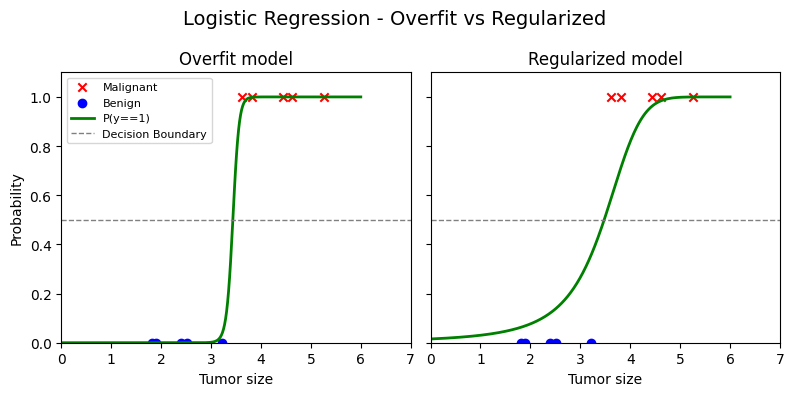

In [295]:
fig, ax = plt.subplots(1, 2, figsize=(8,4), sharey=True)

for i in range(len(ax)):
    ax[i].scatter(X_train[y_train==1], y_train[y_train==1], marker = 'x', c='red', label='Malignant')
    ax[i].scatter(X_train[y_train==0], y_train[y_train==0], marker = 'o', c='blue', label='Benign')
    ax[i].plot(X_plt, plots[i], c='green', lw=2, label='P(y==1)')
    ax[i].axhline(0.5, c='grey', linestyle='--', lw=1, label='Decision Boundary')
    ax[i].set_xlabel('Tumor size')
    ax[i].set_title(titles[i])
    ax[i].axis([0,7,0,1.1])

ax[0].set_ylabel('Probability') 
ax[0].legend(fontsize=8)    


fig.suptitle("Logistic Regression - Overfit vs Regularized", fontsize=14)
plt.tight_layout()
plt.show()


## Prediction on New Data
Predicting malignancy probability for a new tumor of size 3.3. Same preprocessing pipeline applied — feature engineering then normalize with training mu and sigma.

In [296]:
X_new = np.array([[3.3]])
X_new_eng = np.hstack([X_new**i for i in range(1, degree+1)])
X_new_norm = (X_new_eng - mu) / sigma
y1 = np.dot(X_new_norm,w_overfit) + b_overfit
g1 = sigmoid(y1)
y2 = np.dot(X_new_norm,w_regularized) + b_regularized
g2 = sigmoid(y2)

## Significance of Regularization

Tumor size 3.3 sits closer to the malignant class mean (4.0) than to the benign mean (2.0)
— only 0.7 units away from malignant vs 1.3 units from benign.
A well-calibrated model should reflect this uncertainty and lean toward malignant.

For the first batch of random numbers generated,
- Unregularized model: 10.90% — confidently calls it benign. Wrong.
  The oscillating decision boundary misclassifies this region entirely.

- Regularized model: 39.87% — uncertain, but leaning in the right direction.
  The smooth S-curve correctly reflects that 3.3 is ambiguous but closer to the malignant cluster.

In a medical context, the overfit model's overconfidence is dangerous.
Regularization doesn't just improve accuracy — it produces calibrated uncertainty,
which matters when the cost of a false negative is high.

In [297]:
print(f"Probability calculated by unregularized model for tumor size 3.3 being malignant is: {g1[0]*100:.2f}%")
print(f"Probability calculated by regularized model for tumor size 3.3 being malignant is: {g2[0]*100:.2f}%")

Probability calculated by unregularized model for tumor size 3.3 being malignant is: 10.90%
Probability calculated by regularized model for tumor size 3.3 being malignant is: 39.87%
